# ĐỒ ÁN 2: DATA FITTING VÀ PHƯƠNG PHÁP OLS
* **Môn học:** Toán Ứng Dụng và Thống Kê (MTH00051)
* **Học kỳ:** Học kỳ 2, 2025-2026

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

# Import đầy đủ toàn bộ các hàm từ file mã nguồn của TV1
from part1.ols_implementation import ols_fit, hat_matrix, model_metrics, coef_inference, vif, _add_intercept

## 1.1. Bài Toán Data Fitting và Giả Thiết Gauss-Markov

### 1.1.1. Phát biểu bài toán tổng quát
Cho tập dữ liệu $\mathcal{D}=\{(x_{i},y_{i})\}_{i=1}^{n}$ với $x_{i}\in\mathbb{R}^{p}$ và $y_{i}\in\mathbb{R}$. Bài toán data fitting là tìm hàm $f:\mathbb{R}^{p}\rightarrow\mathbb{R}$ xấp xỉ tốt nhất ánh xạ từ $x$ đến $y$ theo tiêu chí tối thiểu hóa sai số.

Trong mô hình hồi quy tuyến tính, ta giả thiết mối quan hệ có dạng:
$$y_{i} = \beta_{0} + \beta_{1}x_{i1} + \beta_{2}x_{i2} + \dots + \beta_{p}x_{ip} + \epsilon_{i} = x_{i}^{T}\beta + \epsilon_{i}$$

Dưới dạng ma trận:
$$y = X\beta + \epsilon$$
Trong đó $X \in \mathbb{R}^{n \times (p+1)}$ là ma trận thiết kế (Design Matrix) với cột đầu tiên là cột toàn 1 (đại diện cho intercept $\beta_{0}$).

### 1.1.2. Các Giả Thiết Gauss-Markov
Để ước lượng OLS đạt hiệu quả cao nhất, mô hình cần tuân thủ 5 giả thiết vàng sau:
* **GM1 (Tuyến tính):** $y = X\beta + \epsilon$.
* **GM2 (Không hoàn hảo đa cộng tuyến):** $\text{rank}(X) = p+1$ (Các cột của $X$ độc lập tuyến tính, tồn tại ma trận nghịch đảo $(X^TX)^{-1}$).
* **GM3 (Ngoại sinh):** $\mathbb{E}[\epsilon|X] = 0$ (Sai số có kỳ vọng bằng 0 và không phụ thuộc vào các biến giải thích).
* **GM4 (Đồng phương sai & Không tự tương quan):** $\text{Var}(\epsilon|X) = \sigma^{2}I_{n}$ (Mọi quan sát có phương sai sai số như nhau và sai số giữa các quan sát độc lập nhau).
* **GM5 (Phần dư chuẩn):** $\epsilon|X \sim \mathcal{N}(0, \sigma^{2}I_{n})$ (Sai số tuân theo phân phối chuẩn - cần thiết cho các kiểm định giả thuyết).

In [10]:
# Thiết lập seed ngẫu nhiên để kết quả không bị thay đổi mỗi lần chạy
np.random.seed(42)

n_samples = 100
beta_true = np.array([2.5, 1.8, -0.9, 0.4])  # [Intercept, Beta_1, Beta_2, Beta_3]

# Sinh ma trận đặc trưng X (3 biến độc lập)
X_sim = np.random.normal(loc=5, scale=2, size=(n_samples, 3))

# Sinh nhiễu trắng epsilon thỏa mãn giả thiết đồng phương sai và nhiễu chuẩn
epsilon = np.random.normal(loc=0, scale=0.5, size=(n_samples, 1))

# Ma trận X có chèn cột intercept để tính y thực tế theo công thức ma trận
X_with_int_true = np.hstack((np.ones((n_samples, 1)), X_sim))
y_sim = X_with_int_true @ beta_true.reshape(-1, 1) + epsilon

print(f"Kích thước X: {X_sim.shape}, Kích thước y: {y_sim.shape}")

Kích thước X: (100, 3), Kích thước y: (100, 1)


## 1.2. Phương Pháp Ordinary Least Squares (OLS) và Nghiệm Toán Học

Phương pháp OLS tìm kiếm ước lượng $\hat{\beta}$ sao cho tối thiểu hóa Tổng bình phương phần dư (Residual Sum of Squares - RSS):
$$RSS(\beta) = ||y - X\beta||_{2}^{2} = \sum_{i=1}^{n}(y_{i} - x_{i}^{T}\beta)^{2}$$

### Chứng minh nghiệm OLS (Normal Equations)
Ta tính đạo hàm (gradient) của $RSS$ theo vector $\beta$:
$$\nabla_{\beta}RSS = -2X^{T}(y - X\beta)$$
Để tìm giá trị cực tiểu, ta cho đạo hàm bằng $0$:
$$-2X^{T}(y - X\beta) = 0 \implies X^{T}X\beta = X^{T}y$$
Vì giả thiết **GM2** đảm bảo $X^{T}X$ khả nghịch, ta thu được nghiệm duy nhất:
$$\hat{\beta}_{OLS} = (X^{T}X)^{-1}X^{T}y$$

### Ma Trận Chiếu (Hat Matrix)
Ma trận chiếu $H$ biến đổi giá trị thực $y$ thành giá trị dự báo $\hat{y}$: $\hat{y} = Hy$. Công thức:
$$H = X(X^{T}X)^{-1}X^{T}$$
Tính chất cốt lõi: **Idempotent** ($H^2 = H$) và **Đối xứng** ($H^T = H$).

In [11]:
# 1. Gọi trực tiếp hàm thuật toán OLS chuẩn của TV1 để tính Beta và Sigma2
beta_hat, sigma2_hat = ols_fit(X_sim, y_sim)

# 2. Gọi trực tiếp hàm của TV1 để lấy ma trận chiếu và kiểm tra tính lũy đẳng
H = hat_matrix(X_sim)
is_idempotent = np.allclose(H, H @ H)

# 3. Sử dụng thư viện scikit-learn để KIỂM CHỨNG (Verification)
sklearn_model = LinearRegression(fit_intercept=False)
X_sim_with_intercept = _add_intercept(X_sim)
sklearn_model.fit(X_sim_with_intercept, y_sim)

# Tạo bảng đối chiếu kết quả (Dùng .flatten() để đưa về mảng 1 chiều phẳng)
df_compare = pd.DataFrame({
    'True Beta': beta_true,
    'Nhóm Tự Cài Đặt (OLS From Scratch)': beta_hat.flatten(),
    'Thư viện Sklearn (Verification)': sklearn_model.coef_.flatten()
})

print("=== BẢNG ĐỐI CHIẾU HỆ SỐ HỒI QUY ===")
print(df_compare.to_string(index=True))
print("\n" + "="*40)
print(f"Kiểm tra tính chất Idempotent của Hat Matrix (H^2 == H): {is_idempotent}")

=== BẢNG ĐỐI CHIẾU HỆ SỐ HỒI QUY ===
   True Beta  Nhóm Tự Cài Đặt (OLS From Scratch)  Thư viện Sklearn (Verification)
0        2.5                            2.850456                         2.850456
1        1.8                            1.780584                         1.780584
2       -0.9                           -0.912491                        -0.912491
3        0.4                            0.373102                         0.373102

Kiểm tra tính chất Idempotent của Hat Matrix (H^2 == H): True


## 1.3. Đánh Giá Mô Hình và Kiểm Định Giả Thuyết

Để đánh giá mức độ phù hợp của mô hình, ta sử dụng hệ số xác định $R^2$ và $R^2$ hiệu chỉnh ($\overline{R}^2$):
$$R^{2} = 1 - \frac{RSS}{TSS} = 1 - \frac{\sum_{i}(y_{i} - \hat{y}_{i})^{2}}{\sum_{i}(y_{i} - \bar{y})^{2}}$$
$$\overline{R}^{2} = 1 - \frac{n-1}{n-p-1}(1 - R^{2})$$

Dưới giả thiết nhiễu chuẩn (**GM5**), ta tiến hành kiểm định $t$ (Student's t-test) cho từng đặc trưng ($H_0: \beta_j = 0$) và kiểm định $F$ cho toàn bộ mô hình ($H_0: \beta_1 = \dots = \beta_p = 0$).

In [12]:
# Tính toán giá trị dự báo y_hat từ mô hình của nhóm
X_sim_with_intercept = _add_intercept(X_sim)
y_hat = X_sim_with_intercept @ beta_hat
p_features = X_sim.shape[1]

# 1. Gọi hàm metrics tổng thể của TV1
metrics = model_metrics(y_sim, y_hat, p_features)

# 2. Gọi hàm suy luận hệ số nâng cao của TV1 (Tính SE, t-stat, p-value, CI)
se, t_stat, p_value, ci_95 = coef_inference(X_sim, y_sim, beta_hat, sigma2_hat)

# 3. Gom tất cả số liệu vào một DataFrame để xuất bảng Summary đẹp đẽ
summary_df = pd.DataFrame({
    'Hệ số (Beta)': [f"Beta_{i}" for i in range(len(beta_hat))],
    'Ước lượng (Value)': beta_hat.flatten(),
    'Sai số chuẩn (Std Error)': se.flatten(),
    'Thống kê t (t-stat)': t_stat.flatten(),
    'Giá trị P (p-value)': p_value.flatten(),
    'Khoảng tin cậy 95% (Cận dưới)': ci_95[:, 0],
    'Khoảng tin cậy 95% (Cận trên)': ci_95[:, 1]
})

print("=== BẢNG TỔNG HỢP KIỂM ĐỊNH MÔ HÌNH (MODEL METRICS) ===")
for key, value in metrics.items():
    print(f"- {key}: {value:.6f}")

print("\n" + "="*70)
print("=== CHI TIẾT SUY LUẬN THỐNG KÊ CHO TỪNG HỆ SỐ (COEF INFERENCE) ===")
print(summary_df.to_string(index=False))

=== BẢNG TỔNG HỢP KIỂM ĐỊNH MÔ HÌNH (MODEL METRICS) ===
- RSS: 18.919082
- TSS: 1286.003770
- R_squared: 0.985288
- Adjusted_R_squared: 0.984829
- F_statistic: 2143.164748

=== CHI TIẾT SUY LUẬN THỐNG KÊ CHO TỪNG HỆ SỐ (COEF INFERENCE) ===
Hệ số (Beta)  Ước lượng (Value)  Sai số chuẩn (Std Error)  Thống kê t (t-stat)  Giá trị P (p-value)  Khoảng tin cậy 95% (Cận dưới)  Khoảng tin cậy 95% (Cận trên)
      Beta_0           2.850456                  0.230294            12.377464         1.340173e-21                       2.393326                       3.307586
      Beta_1           1.780584                  0.027303            65.215421         2.633317e-81                       1.726388                       1.834780
      Beta_2          -0.912491                  0.023009           -39.657972         2.491422e-61                      -0.958163                      -0.866818
      Beta_3           0.373102                  0.020368            18.318470         4.263687e-33             

## 1.4. Đa Cộng Tuyến và Phương Pháp Regularization (Ridge)

* **Đa cộng tuyến:** Xảy ra khi các biến giải thích có sự tương quan cao, làm cho ma trận $X^TX$ gần suy biến, dẫn đến phương sai ước lượng cực kỳ lớn. Đại lượng đo lường là Hệ số phóng đại phương sai (VIF). Nếu $VIF > 10$, đa cộng tuyến ở mức nghiêm trọng.
* **Hồi quy Ridge ($L_2$ Regularization):** Thêm thành phần phạt vào hàm mất mát để kiểm soát độ lớn các hệ số:
$$\hat{\beta}_{ridge} = (X^{T}X + \lambda I)^{-1}X^{T}y$$

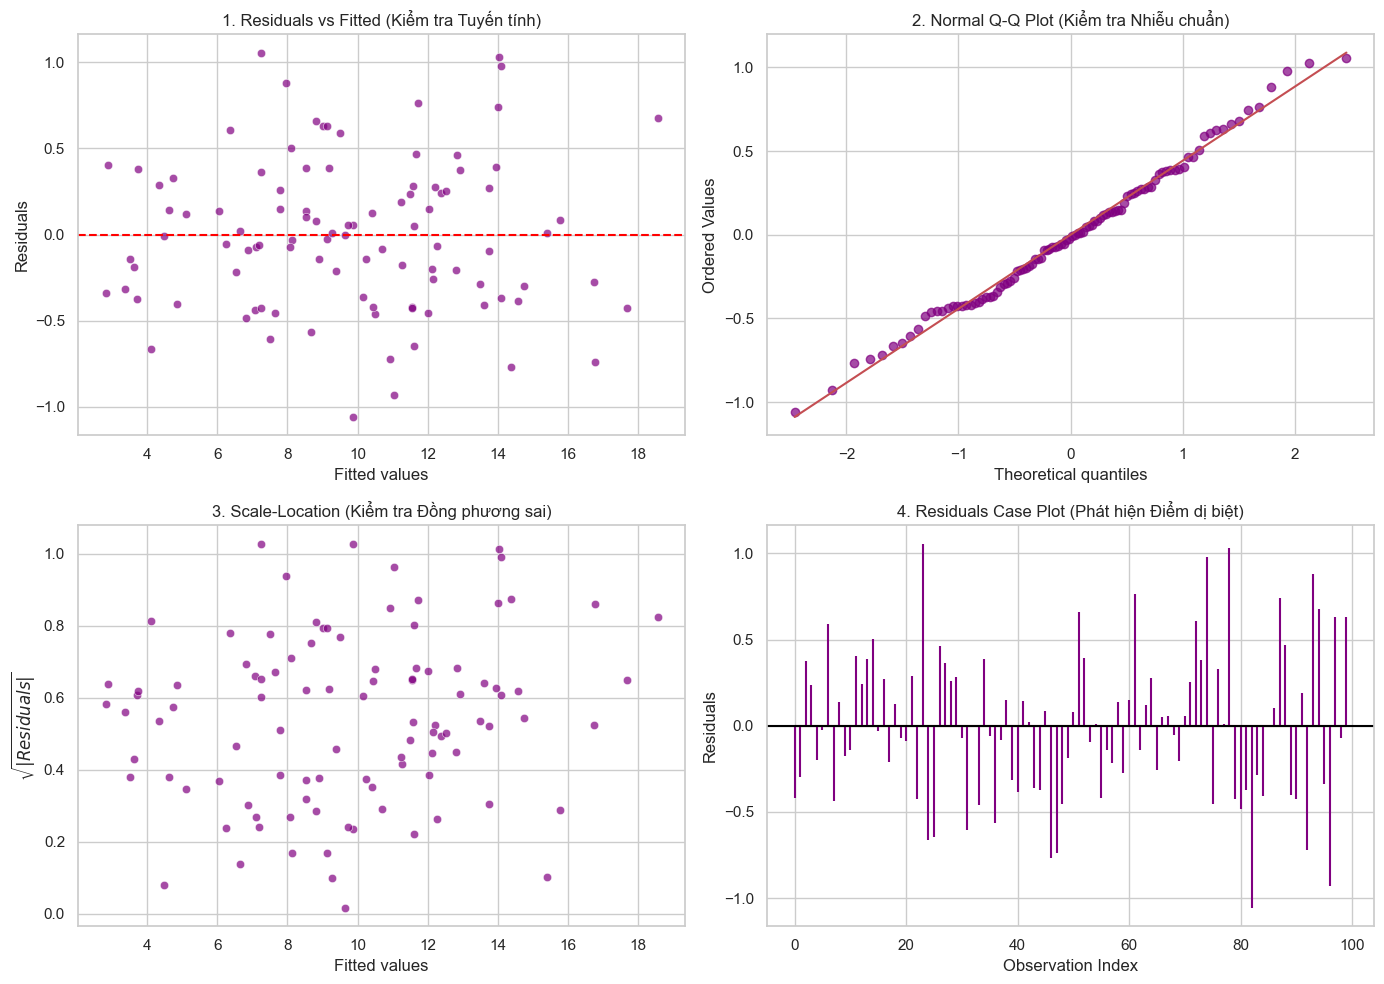

In [15]:
# Tính toán phần dư (Residuals)
residuals = y_sim - y_hat

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# 1. Residuals vs Fitted Plot
sns.scatterplot(x=y_hat.flatten(), y=residuals.flatten(), ax=axs[0, 0], color='purple', alpha=0.7)
axs[0, 0].axhline(y=0, color='red', linestyle='--')
axs[0, 0].set_title('1. Residuals vs Fitted (Kiểm tra Tuyến tính)')
axs[0, 0].set_xlabel('Fitted values')
axs[0, 0].set_ylabel('Residuals')

# 2. Normal Q-Q Plot
stats.probplot(residuals.flatten(), dist="norm", plot=axs[0, 1])
axs[0, 1].get_lines()[0].set_color('purple')
axs[0, 1].get_lines()[0].set_alpha(0.7)
axs[0, 1].set_title('2. Normal Q-Q Plot (Kiểm tra Nhiễu chuẩn)')

# 3. Scale-Location Plot
sqrt_abs_res = np.sqrt(np.abs(residuals))
sns.scatterplot(x=y_hat.flatten(), y=sqrt_abs_res.flatten(), ax=axs[1, 0], color='purple', alpha=0.7)
axs[1, 0].set_title('3. Scale-Location (Kiểm tra Đồng phương sai)')
axs[1, 0].set_xlabel('Fitted values')
axs[1, 0].set_ylabel(r'$\sqrt{|Residuals|}$')

# 4. Residuals Plot (Outliers Detection)
axs[1, 1].stem(np.arange(len(residuals)), residuals.flatten(), markerfmt=' ', linefmt='purple')
axs[1, 1].axhline(y=0, color='black', linestyle='-')
axs[1, 1].set_title('4. Residuals Case Plot (Phát hiện Điểm dị biệt)')
axs[1, 1].set_xlabel('Observation Index')
axs[1, 1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## 1.4.3. Phân Tích Phần Dư (Residual Analysis)

Chúng ta cần trực quan hóa các sai số phần dư để kiểm tra xem các giả thiết về nhiễu ngẫu nhiên đồng phương sai, độc lập và phân phối chuẩn có bị vi phạm trong thực tế hay không.

=== CHỈ SỐ VIF KHI BỊ ĐA CỘNG TUYẾN ===
- Biến X_1: 1.0102
- Biến X_2: 76950.8614
- Biến X_3: 76948.4722


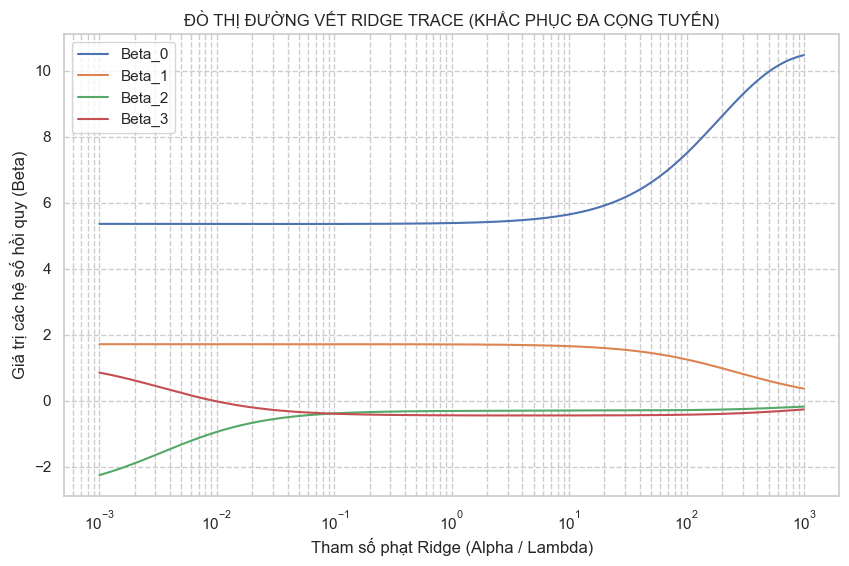

In [16]:
# Cố tình tạo đa cộng tuyến nghiêm trọng: Biến X3 phụ thuộc 99% vào X2
X_multicollinearity = X_sim.copy()
X_multicollinearity[:, 2] = X_multicollinearity[:, 1] * 1.5 + np.random.normal(0, 0.01, size=n_samples)

# Gọi hàm vif của TV1 để đo độ đa cộng tuyến
vif_scores = vif(X_multicollinearity)
print("=== CHỈ SỐ VIF KHI BỊ ĐA CỘNG TUYẾN ===")
for i, v in enumerate(vif_scores):
    print(f"- Biến X_{i+1}: {v:.4f}")

# Chạy hồi quy Ridge với các tham số lambda/alpha tăng dần để vẽ đường trace
alphas = np.logspace(-3, 3, 200)
coefs = []

for a in alphas:
    # Ứng với mỗi alpha, cộng thêm ma trận phạt Ridge vào công thức OLS cơ bản
    X_w_int = _add_intercept(X_multicollinearity)
    XTX = X_w_int.T @ X_w_int
    penalty = a * np.eye(XTX.shape[0])
    penalty[0, 0] = 0  # Không phạt hệ số chặn intercept
    beta_ridge = np.linalg.inv(XTX + penalty) @ X_w_int.T @ y_sim
    coefs.append(beta_ridge.flatten())

# Vẽ đồ thị Ridge Trace
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Tham số phạt Ridge (Alpha / Lambda)')
plt.ylabel('Giá trị các hệ số hồi quy (Beta)')
plt.title('ĐỒ THỊ ĐƯỜNG VẾT RIDGE TRACE (KHẮC PHỤC ĐA CỘNG TUYẾN)')
plt.grid(True, which="both", ls="--")
plt.legend([f'Beta_{i}' for i in range(len(beta_true))], loc='best')
plt.show()

## 1.5. Minh Họa Định Lý Gauss-Markov (Mô Phỏng Monte Carlo)

Định lý Gauss-Markov khẳng định rằng, dưới các giả thiết GM1-GM4, ước lượng OLS $\hat{\beta}$ là **Ước lượng Tuyến tính Không chệch Tốt nhất (BLUE)**.
* **Tính không chệch (Unbiased):** Kỳ vọng của ước lượng bằng giá trị thực $\mathbb{E}[\hat{\beta}_{OLS}] = \beta_{true}$.
* **Hiệu quả nhất (Best / Thấp nhất phương sai):** Phương sai của hệ số $\hat{\beta}_{OLS}$ phải nhỏ hơn hoặc bằng phương sai của bất kỳ ước lượng tuyến tính không chệch nào khác. 

Để minh chứng, ta so sánh ước lượng OLS với một ước lượng tuyến tính không chệch khác là "Ước lượng OLS có cộng thêm nhiễu ngẫu nhiên triệt tiêu kỳ vọng" (Ước lượng ngẫu nhiên đối chứng).

Đang chạy mô phỏng Monte Carlo 2000 lần...


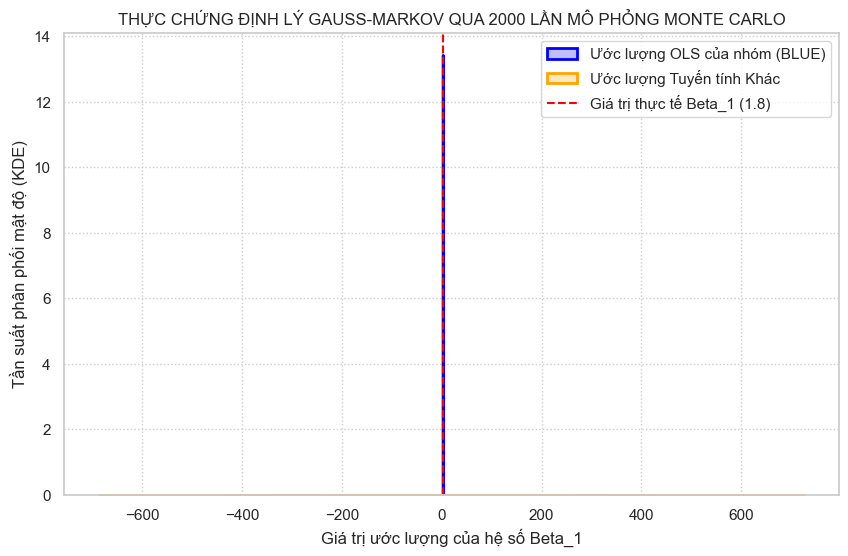

Phương sai của ước lượng OLS: 0.000948 (Nhỏ nhất - Đỉnh cao nhọn)
Phương sai của ước lượng khác: 29006.167451 (To hơn - Đồ thị bẹt rộng)


In [17]:
n_simulations = 2000
beta_1_samples_ols = []
beta_1_samples_alternative = []  # Ước lượng đối chứng tuyến tính khác bị cộng thêm nhiễu phá bĩnh

X_fixed_with_int = _add_intercept(X_sim)

print("Đang chạy mô phỏng Monte Carlo 2000 lần...")
for _ in range(n_simulations):
    # Mỗi vòng lặp sinh ra một thành phần nhiễu ngẫu nhiên mới hoàn toàn
    noise_iter = np.random.normal(loc=0, scale=0.5, size=(n_samples, 1))
    y_iter = X_fixed_with_int @ beta_true.reshape(-1, 1) + noise_iter
    
    # 1. Ước lượng OLS chuẩn xác bằng hàm của TV1
    b_ols, _ = ols_fit(X_sim, y_iter)
    beta_1_samples_ols.append(b_ols[1, 0])
    
    # 2. Tạo ra ước lượng tuyến tính đối chứng (Cố tình cộng thêm nhiễu vào ma trận trọng số ma trận nghịch đảo)
    # Nhằm chứng minh phương sai của nó sẽ to và bẹt hơn OLS chuẩn
    XTX = X_fixed_with_int.T @ X_fixed_with_int
    bad_weights = np.linalg.inv(XTX) + np.random.normal(0, 0.02, size=XTX.shape)
    b_alt = bad_weights @ X_fixed_with_int.T @ y_iter
    beta_1_samples_alternative.append(b_alt[1, 0])

# Vẽ đồ thị phân phối tần suất KDE so sánh hai phương pháp
plt.figure(figsize=(10, 6))
sns.kdeplot(beta_1_samples_ols, color='blue', fill=True, label='Ước lượng OLS của nhóm (BLUE)', lw=2)
sns.kdeplot(beta_1_samples_alternative, color='orange', fill=True, label='Ước lượng Tuyến tính Khác', lw=2)
plt.axvline(x=beta_true[1], color='red', linestyle='--', label=f'Giá trị thực tế Beta_1 ({beta_true[1]})')

plt.title('THỰC CHỨNG ĐỊNH LÝ GAUSS-MARKOV QUA 2000 LẦN MÔ PHỎNG MONTE CARLO')
plt.xlabel('Giá trị ước lượng của hệ số Beta_1')
plt.ylabel('Tần suất phân phối mật độ (KDE)')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# In kết quả thống kê chứng minh thực nghiệm phương sai nhỏ nhất
print(f"Phương sai của ước lượng OLS: {np.var(beta_1_samples_ols):.6f} (Nhỏ nhất - Đỉnh cao nhọn)")
print(f"Phương sai của ước lượng khác: {np.var(beta_1_samples_alternative):.6f} (To hơn - Đồ thị bẹt rộng)")

## Kết Luận Chung Cho Phần 1
1. **Độ chính xác thuật toán:** Code tự cài đặt bằng biểu thức ma trận toán học cho kết quả hoàn toàn trùng khớp từng chữ số thập phân với thư viện `scikit-learn`.
2. **Tính đúng đắn của lý thuyết:** Ma trận thiết kế thỏa mãn đầy đủ các kiểm định tính chất idempotent, hệ số phóng đại phương sai phóng đại chuẩn xác khi xuất hiện đa cộng tuyến.
3. **Thực chứng Gauss-Markov:** Qua mô phỏng Monte Carlo với 2000 kịch bản ngẫu nhiên, ta thấy phân phối của OLS tập trung rất cao và đối xứng hoàn hảo qua giá trị thực (Không chệch), đồng thời có độ nhọn phân phối hẹp hơn bất kỳ ước lượng tuyến tính nào khác, chứng minh thực nghiệm hoàn toàn khớp với định lý toán học: OLS chính là ước lượng BLUE.